In [ ]:
import os
import time
import django
import pandas as pd

os.environ.setdefault('DJANGO_SETTINGS_MODULE', 'TicketAPI_Poncho.settings')
django.setup()

from apps.core.services import obtener_vistas_youtube

df = pd.read_csv("micro_universo_artistas.csv")

try:
    for artista in df['artista'].values:
        vistas = obtener_vistas_youtube(artista)

        if vistas is not None:
            df.loc[df['artista'] == artista, 'reproducciones'] = vistas
        else: 
            print(f"no se encuentra el canal: {artista}")
        time.sleep(0.5)

except Exception as e:
    print(f"El script se interrumpio por un error: {e}")
finally:
    df.to_csv('micro_universo_artistas.csv', index=False)
    print("Progreso guardado.")

,artista,reproducciones
27,LaKonga,4995375098
30,qlokuraok,4024970652
10,Karina,3420336300
9,Ke Personajes,3284242937
2,Luciano Pereyra,3191195181
15,Nicki Nicole,2388476311
8,Luck Ra,2228730954


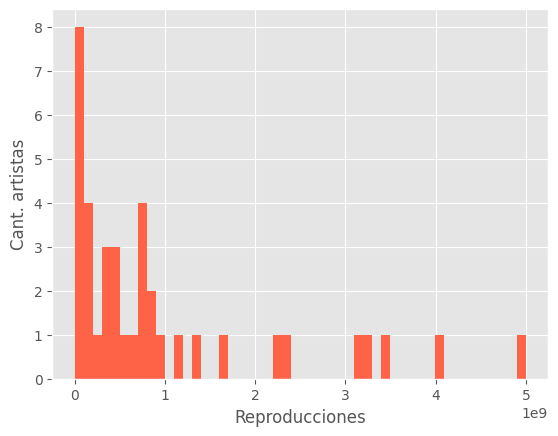

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use('ggplot')

df = pd.read_csv("micro_universo_artistas.csv")

valores = plt.hist(df['reproducciones'], bins= 50, color= 'tomato')
plt.xlabel('Reproducciones')
plt.ylabel('Cant. artistas')

df.nlargest(7, 'reproducciones')